# Customer Segmentation with Clustering
In this section, we apply unsupervised learning techniques to group customers based on their financial behavior and credit history. targeted marketing strategies.
* **Analysis:** RFM (Recency, Frequency, Monetary)
* **Algorithms:** K-Means & DBSCAN Clustering
* **Goal:** To identify customer profiles and develop personalized marketing strategies.

In [1]:
#Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import xgboost as xgb
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split


import warnings 
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
print('Libraries loaded ✓')

Libraries loaded ✓


# Data Upload

In [2]:
#Data Load
DATA_PATH = os.path.join('..','data','online_retail_II.csv')

def get_data(path):
    if not os.path.exists(path):
        print(f"Error: {path} not found! Please check the path.")
        return None

    df = pd.read_csv(path, index_col=0)

    print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
    return df

df = get_data(DATA_PATH)

Data loaded: 1067371 rows, 7 columns.


In [3]:
#First Galance
df.info()
df.describe()
df.head(10)
df = df.reset_index()
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
Index: 1067371 entries, 489434 to 581587
Data columns (total 7 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   StockCode    1067371 non-null  object 
 1   Description  1062989 non-null  object 
 2   Quantity     1067371 non-null  int64  
 3   InvoiceDate  1067371 non-null  object 
 4   Price        1067371 non-null  float64
 5   Customer ID  824364 non-null   float64
 6   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 65.1+ MB
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


# Data Cleaning

In [4]:
print("--- Missing Values ---")
print(df.isnull().sum())
print("--- General Statistics ---")
print(df.describe())

--- Missing Values ---
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
--- General Statistics ---
           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4.649388e+00   15324.638504
std    1.727058e+02  1.235531e+02    1697.464450
min   -8.099500e+04 -5.359436e+04   12346.000000
25%    1.000000e+00  1.250000e+00   13975.000000
50%    3.000000e+00  2.100000e+00   15255.000000
75%    1.000000e+01  4.150000e+00   16797.000000
max    8.099500e+04  3.897000e+04   18287.000000


In [5]:
#Cleaning

# 1.Remove spaces from column names
df.columns = df.columns.str.strip()

# 2.Remove those without a customer ID.
df.dropna(subset=["Customer ID"], inplace=True)

# 3.Remove Quantity and Price that are negative or zero.
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

# 4.Convert InvoiceDate to datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# 5.Calculate the total amount for each line.
df["TotalPrice"] = df["Quantity"] * df["Price"]

# 6.Remove return procedures
df = df[~df["Invoice"].astype(str).str.startswith("C")]

print(f"Data size after cleaning: {df.shape}")
print(f"Remaining number of unique customers: {df['Customer ID'].nunique()}")

Data size after cleaning: (805549, 9)
Remaining number of unique customers: 5878


# RFM Calculation

In [6]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Analysis Date: {analysis_date.date()}")

rfm = df.groupby("Customer ID").agg(
    Recency = ("InvoiceDate", lambda x: (analysis_date - x.max()).days),
    Frequency = ("Invoice", "nunique"),
    Monetary = ("TotalPrice", "sum")
).reset_index()

print(rfm.describe())
print(rfm.head(10))

Analysis Date: 2011-12-10
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.000000    2307.090000
max    18287.000000   739.000000   398.000000  608821.650000
   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   5633.32
2      12348.0       75          5   2019.40
3      12349.0       19          4   4428.69
4      12350.0      310          1    334.40
5      12351.0      375          1    300.93
6      12352.0       36         10   2849.84
7      12353.0      204          2    406.76
8      12354.0      

# RFM Scoring

In [7]:
#Recency
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, labels=[5,4,3,2,1])

#Frequency
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1,2,3,4,5])

#Monetary
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), q=5, labels=[1,2,3,4,5])

rfm[["R_Score","F_Score","M_Score"]] = rfm[["R_Score","F_Score","M_Score"]].astype(int)

rfm["RFM_Score"] = (rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str))

rfm["RFM_Total"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

print(rfm[["Customer ID","Recency","Frequency","Monetary","R_Score","F_Score","M_Score","RFM_Score"]].head(10))

   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0      12346.0      326         12  77556.46        2        5        5   
1      12347.0        2          8   5633.32        5        4        5   
2      12348.0       75          5   2019.40        3        4        4   
3      12349.0       19          4   4428.69        5        3        5   
4      12350.0      310          1    334.40        2        1        2   
5      12351.0      375          1    300.93        2        1        2   
6      12352.0       36         10   2849.84        4        5        4   
7      12353.0      204          2    406.76        2        2        2   
8      12354.0      232          1   1079.40        2        1        3   
9      12355.0      214          2    947.61        2        2        3   

  RFM_Score  
0       255  
1       545  
2       344  
3       535  
4       212  
5       212  
6       454  
7       222  
8       213  
9       223  


# EDA

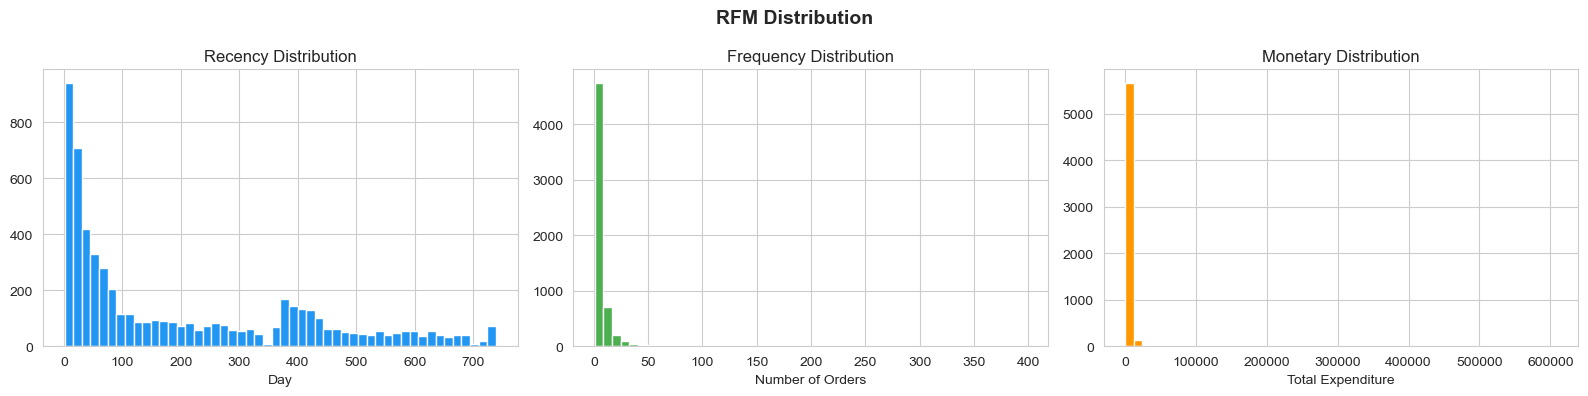

In [8]:
#RFM GRAPHS
fig, axes = plt.subplots(1, 3, figsize=(16,4))

axes[0].hist(rfm["Recency"], bins=50, color="#2196F3", edgecolor="white")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Day")

axes[1].hist(rfm["Frequency"], bins=50, color="#4CAF50", edgecolor="white")
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Orders")

axes[2].hist(rfm["Monetary"], bins=50, color="#FF9800", edgecolor="white")
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Expenditure")

plt.suptitle("RFM Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/rfm_distribution.png")
plt.show()

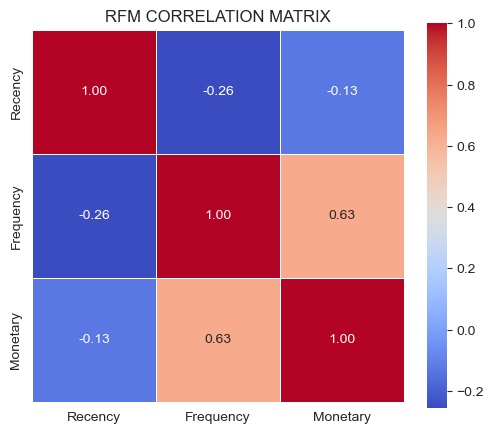

In [9]:
#CORRELATION MATRIX

corr = rfm[["Recency","Frequency","Monetary"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("RFM CORRELATION MATRIX")
plt.savefig("../images/rfm_correlation_matrix.png")
plt.show()

# K-Means Clustering

In [10]:
rfm_scaled = rfm[["Recency","Frequency","Monetary"]].copy()
rfm_scaled["Frequency"] = np.log1p(rfm_scaled["Frequency"])
rfm_scaled["Monetary"] = np.log1p(rfm_scaled["Monetary"])

scaler = StandardScaler()
rfm_array = scaler.fit_transform(rfm_scaled)

print("Scaled data - first 5 rows:")
print(pd.DataFrame(rfm_array, columns=["Recency","Frequenct","Monetary"]).head)

Scaled data - first 5 rows:
<bound method NDFrame.head of        Recency  Frequenct  Monetary
0     0.595584   1.254496  3.186625
1    -0.952279   0.800166  1.297127
2    -0.603532   0.299207  0.558100
3    -0.871064   0.073946  1.123790
4     0.519146  -1.058146 -0.735888
...        ...        ...       ...
5873 -0.942724   1.959413  0.777020
5874  1.101983  -1.058146 -0.504065
5875  2.195997  -1.058146 -0.560208
5876  1.316964  -0.557187  0.238942
5877 -0.756408   0.654643  1.082670

[5878 rows x 3 columns]>


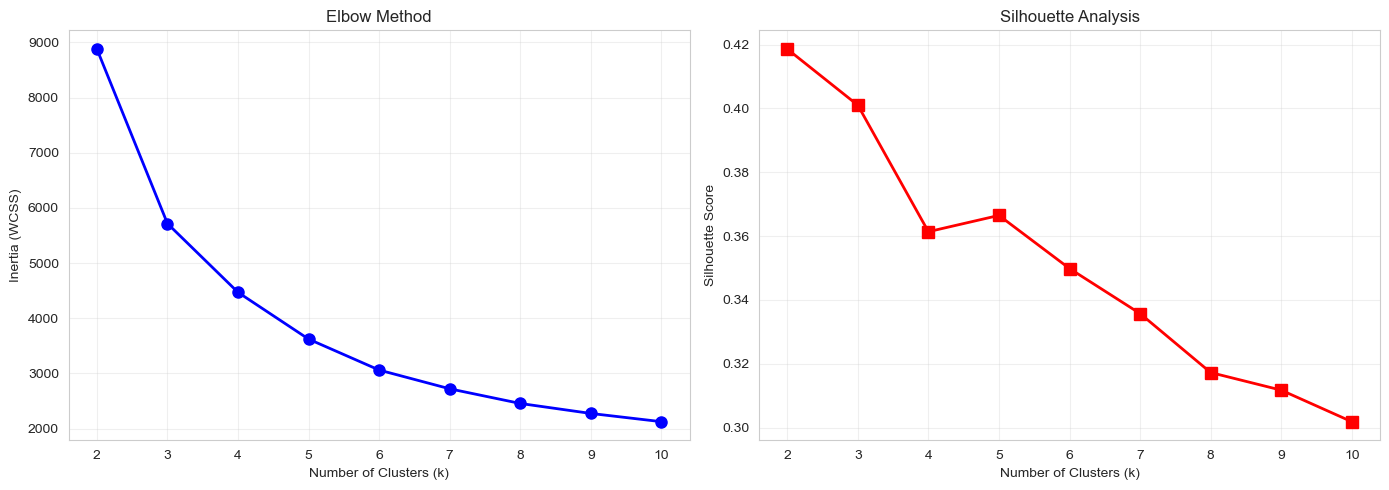


Silhouette Scores:
k=2: 0.4186
k=3: 0.4010
k=4: 0.3614
k=5: 0.3665
k=6: 0.3499
k=7: 0.3357
k=8: 0.3173
k=9: 0.3117
k=10: 0.3019


In [11]:
#ELBOW METHOD

inertias= []
silhouettes = []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(rfm_array)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_array, km.labels_))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

ax1.plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_title("Elbow Method")
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouettes, "rs-", linewidth=2, markersize=8)
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Analysis")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../images/elbow_silhouette.png")
plt.show()

print("\nSilhouette Scores:")
for k, s in zip(K_range, silhouettes):
    print(f"k={k}: {s:.4f}")

In [12]:
#K-MEANS MODEL

BEST_K = 5
km_final = KMeans(n_clusters=BEST_K, init="k-means++", n_init=10, random_state=42)

rfm["KMeans_Cluster"] = km_final.fit_predict(rfm_array)

print(f"\nK-Means (k={BEST_K}) cluster distribution:")
print(rfm["KMeans_Cluster"].value_counts().sort_index())


K-Means (k=5) cluster distribution:
KMeans_Cluster
0    1349
1     911
2    1688
3     850
4    1080
Name: count, dtype: int64


# DBSCAN

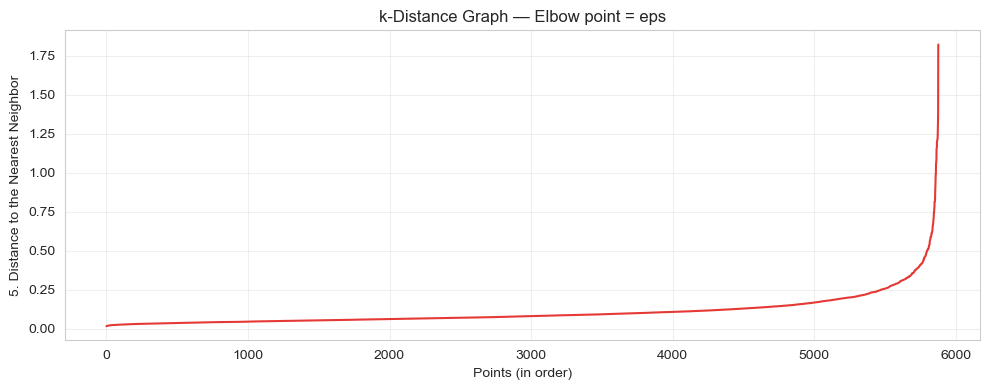

In [13]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(rfm_array)
distances, _ = neighbors.kneighbors(rfm_array)

dist_sorted = np.sort(distances[:, 4])

plt.figure(figsize=(10,4))
plt.plot(dist_sorted, linewidth=1.5, color="#E53935")
plt.xlabel("Points (in order)")
plt.ylabel("5. Distance to the Nearest Neighbor")
plt.title("k-Distance Graph — Elbow point = eps")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../images/nearest_neighbors.png")
plt.show()

In [14]:
EPS = 0.35
MIN_SAMPLES = 5

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
rfm["DBSCAN_Cluster"] = dbscan.fit_predict(rfm_array)

n_clusters = len(set(rfm["DBSCAN_Cluster"])) - (1 if -1 in rfm["DBSCAN_Cluster"].values else 0)
n_noise = (rfm["DBSCAN_Cluster"] == -1).sum()

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise (outliers): {n_noise} (%{n_noise/len(rfm)*100:.1f})")
print(f"\nCluster distribution:")
print(rfm["DBSCAN_Cluster"].value_counts().sort_index())

Number of clusters found: 3
Number of noise (outliers): 113 (%1.9)

Cluster distribution:
DBSCAN_Cluster
-1     113
 0    3225
 1    1608
 2     932
Name: count, dtype: int64


# Visualization (2D with PCA)

PCA explained variance:%95.1


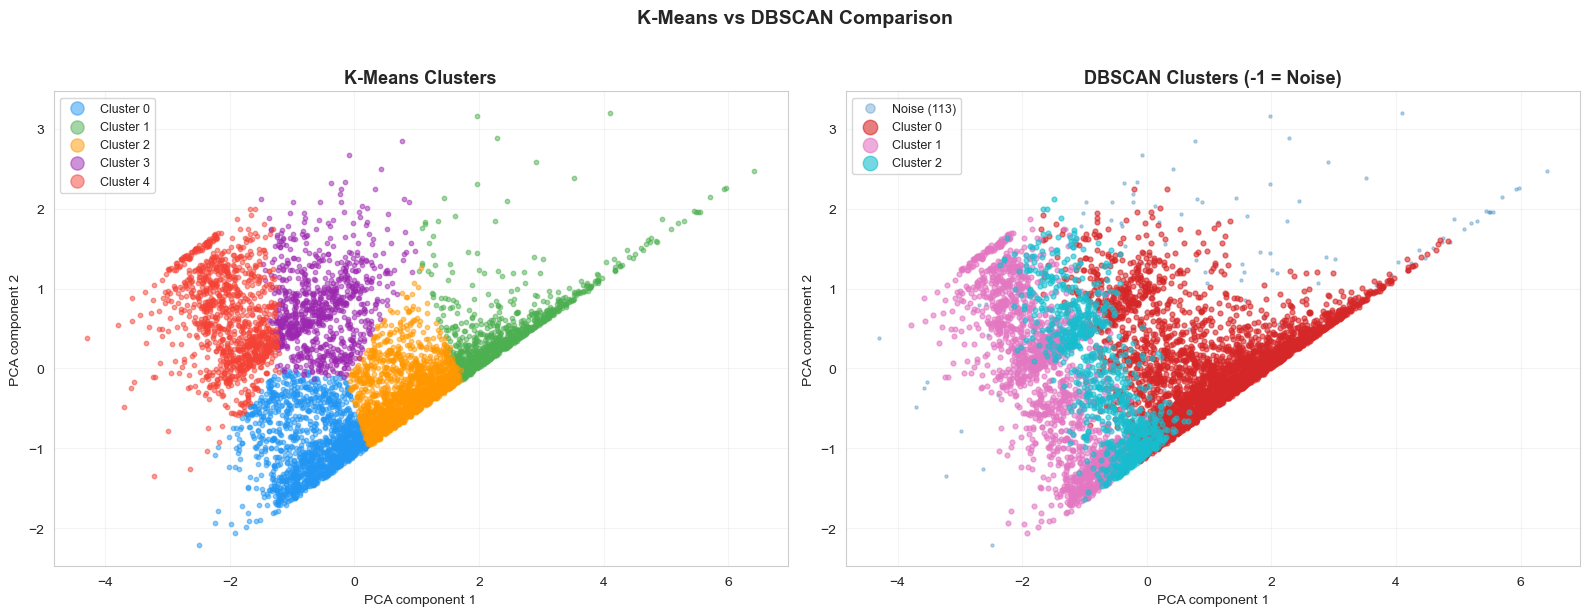

In [15]:
pca = PCA(n_components=2, random_state=42)
rfm_2d = pca.fit_transform(rfm_array)

print(f"PCA explained variance:" f"%{pca.explained_variance_ratio_.sum()*100:.1f}")

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,6))

#K-Means (k = 5)
colors_km = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336"]
for cluster in range(5):
    mask = rfm["KMeans_Cluster"] == cluster
    ax1.scatter(rfm_2d[mask, 0], rfm_2d[mask, 1],
               c=colors_km[cluster], alpha=0.5, s=10,
               label=f"Cluster {cluster}")

ax1.set_title(f"K-Means Clusters", fontsize=13, fontweight="bold")
ax1.set_xlabel("PCA component 1")
ax1.set_ylabel("PCA component 2")
ax1.legend(markerscale=3, fontsize=9)
ax1.grid(True, alpha = 0.2)

# DBSCAN
unique_labels = sorted(rfm["DBSCAN_Cluster"].unique())
colors_db = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(unique_labels, colors_db):
    mask  = rfm["DBSCAN_Cluster"] == label
    name  = f"Noise ({mask.sum()})" if label == -1 else f"Cluster {label}"
    alpha = 0.3 if label == -1 else 0.6
    size  = 5   if label == -1 else 12
    ax2.scatter(rfm_2d[mask, 0], rfm_2d[mask, 1],
                c=[color], alpha=alpha, s=size, label=name)
ax2.set_title("DBSCAN Clusters (-1 = Noise)", fontsize=13, fontweight="bold")
ax2.set_xlabel("PCA component 1")
ax2.set_ylabel("PCA component 2")
ax2.legend(markerscale=3, fontsize=9)
ax2.grid(True, alpha=0.2)

plt.suptitle("K-Means vs DBSCAN Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../images/kmeans_dbscan_comparison.png")
plt.show()

# Segment Profiles

In [16]:
segment_profile = rfm.groupby("KMeans_Cluster").agg(
    Number_of_Customers = ("Customer ID", "count"),
    Avg_Recency = ("Recency", "mean"),
    Avg_Frequency = ("Frequency", "mean"),
    Avg_Monetary = ("Monetary", "mean"),
    Med_Monetary = ("Monetary", "median")
).round(1)

print("---- K-Means Segment Profile ----")
print(segment_profile)

---- K-Means Segment Profile ----
                Number_of_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
KMeans_Cluster                                                                  
0                              1349        100.6            1.7         420.6   
1                               911         42.0           22.9       13665.8   
2                              1688         63.9            5.7        1970.2   
3                               850        396.0            3.3        1327.9   
4                              1080        523.2            1.2         251.9   

                Med_Monetary  
KMeans_Cluster                
0                      367.9  
1                     6588.4  
2                     1682.1  
3                      950.8  
4                      221.7  


In [17]:
segment_names = {
    0: "🌱 Promising",
    1: "🏆 VIP",
    2: "💛 Loyal Customer",
    3: "😴 Sleeping Customeri",
    4: "💔 Lost Customer"
}

segment_profile["Segment_Name"] = segment_profile.index.map(segment_names)
rfm["Segment_Name"] = rfm["KMeans_Cluster"].map(segment_names)

print("=== SEGMENT TAGS ===")
print(segment_profile[["Segment_Name", "Number_of_Customers",
                         "Avg_Recency", "Avg_Frequency", "Avg_Monetary"]])

=== SEGMENT TAGS ===
                        Segment_Name  Number_of_Customers  Avg_Recency  \
KMeans_Cluster                                                           
0                        🌱 Promising                 1349        100.6   
1                              🏆 VIP                  911         42.0   
2                   💛 Loyal Customer                 1688         63.9   
3               😴 Sleeping Customeri                  850        396.0   
4                    💔 Lost Customer                 1080        523.2   

                Avg_Frequency  Avg_Monetary  
KMeans_Cluster                               
0                         1.7         420.6  
1                        22.9       13665.8  
2                         5.7        1970.2  
3                         3.3        1327.9  
4                         1.2         251.9  


In [18]:
X = rfm_array
y = rfm["KMeans_Cluster"]

X_train , X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, objective='multi:softmax', random_state=42)

xgb_model.fit(X_train, y_train)

print("The XGBoost model has been successfully trained.")

The XGBoost model has been successfully trained.


In [19]:
y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print("---- Model Performance Report ----")
print(f"Accuracy: %{accuracy*100:.2f}")
print(f"Error Rate: %{error_rate*100:.2f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

---- Model Performance Report ----
Accuracy: %98.38
Error Rate: %1.62

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       270
           1       0.99      0.99      0.99       182
           2       0.99      0.98      0.99       338
           3       0.96      0.98      0.97       170
           4       0.98      0.99      0.98       216

    accuracy                           0.98      1176
   macro avg       0.98      0.98      0.98      1176
weighted avg       0.98      0.98      0.98      1176



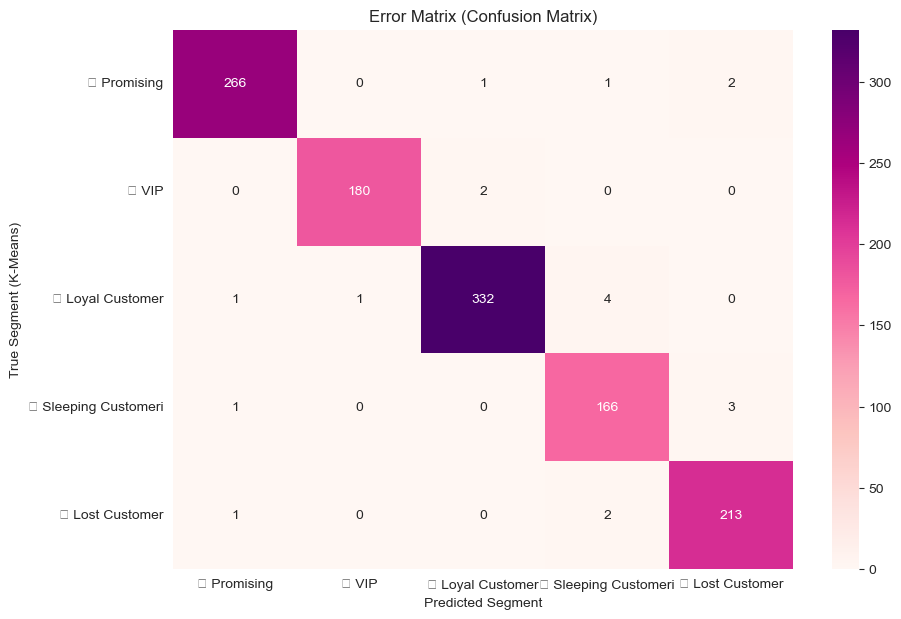

In [22]:
plt.figure(figsize=(10,7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
           xticklabels=segment_names.values(),
           yticklabels=segment_names.values())
plt.xlabel("Predicted Segment")
plt.ylabel("True Segment (K-Means)")
plt.title("Error Matrix (Confusion Matrix)")
plt.savefig("../images/confusion_matrix_xgb.png")
plt.show()

In [ ]:
#SEGMENT DISTRIBUTION

seg_counts  = rfm["Segment_Name"].value_counts()
seg_revenue = rfm.groupby("Segment_Name")["Monetary"].sum().reindex(seg_counts.index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336"]

# Number of Customer
bars1 = ax1.bar(range(len(seg_counts)), seg_counts.values,
                color=colors[:len(seg_counts)], edgecolor="white", linewidth=0.5)
ax1.set_xticks(range(len(seg_counts)))
ax1.set_xticklabels(seg_counts.index, rotation=20, ha="right", fontsize=9)
ax1.set_title("Number of Customers Per Segment", fontweight="bold")
ax1.set_ylabel("Number of Customer")
for bar, val in zip(bars1, seg_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f"{val:,}", ha="center", va="bottom", fontsize=9)
ax1.grid(True, alpha=0.2, axis="y")

# Total revenue
bars2 = ax2.bar(range(len(seg_revenue)), seg_revenue.values,
                color=colors[:len(seg_revenue)], edgecolor="white", linewidth=0.5)
ax2.set_xticks(range(len(seg_revenue)))
ax2.set_xticklabels(seg_revenue.index, rotation=20, ha="right", fontsize=9)
ax2.set_title("Total Revenue Per Segment", fontweight="bold")
ax2.set_ylabel("Total Revenue")
for bar, val in zip(bars2, seg_revenue.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"£{val:,.0f}", ha="center", va="bottom", fontsize=8)
ax2.grid(True, alpha=0.2, axis="y")

plt.suptitle("Segment Analysis — Customer Number and Revenue",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/segment_analysis.png")
plt.show()